In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.distance import pdist, squareform
from scipy.stats import multivariate_normal


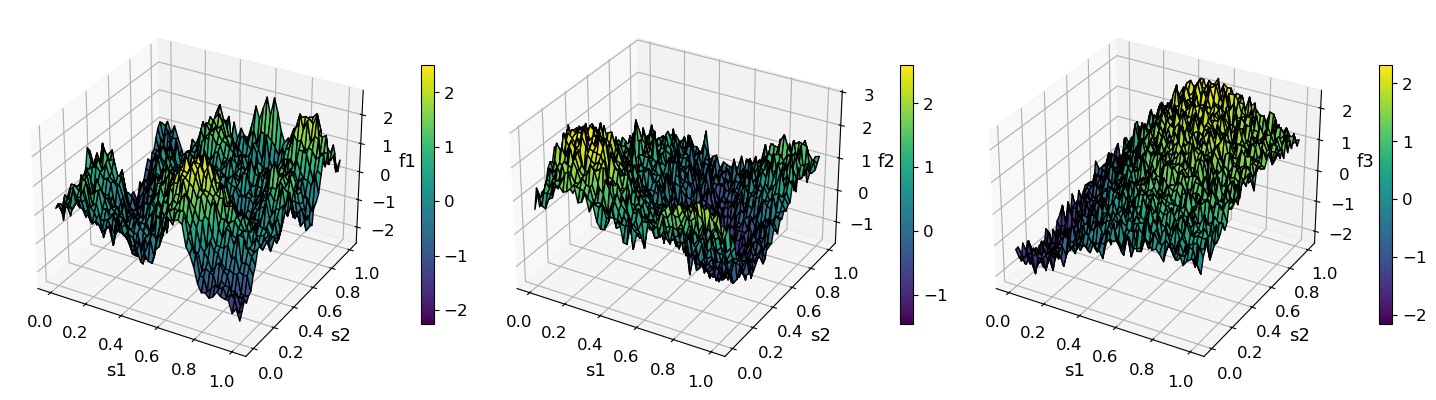

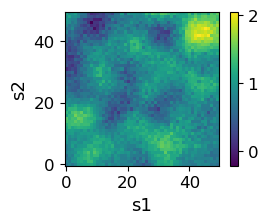

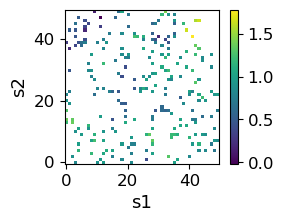

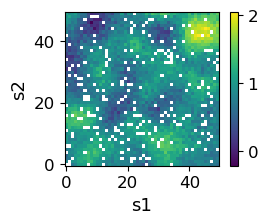

In [38]:
# 定义网格大小和参数
grid_size = 50
x = np.linspace(0, 1, grid_size)
y = np.linspace(0, 1, grid_size)
X, Y = np.meshgrid(x, y)
xy_positions = np.vstack([X.ravel(), Y.ravel()]).T


# 定义高斯协方差函数
def gaussian_covariance(d, variance=1.0, length_scale=0.1, nugget=0.05):
    return variance * np.exp(-d ** 2 / (2 * length_scale ** 2)) + nugget * (d == 0)


# 生成协方差矩阵和随机场
def generate_random_field(length_scale, nugget):
    dists = squareform(pdist(xy_positions))
    cov_matrix = gaussian_covariance(dists, length_scale=length_scale, nugget=nugget)
    return multivariate_normal.rvs(mean=np.zeros(len(xy_positions)), cov=cov_matrix).reshape(grid_size, grid_size)


# 生成三个不同的随机场 f1, f2, f3
f1 = generate_random_field(length_scale=0.1, nugget=0.05)
f2 = generate_random_field(length_scale=0.2, nugget=0.05)
f3 = generate_random_field(length_scale=0.3, nugget=0.05)


# 定义趋势面 T
def trend_surface(X, Y, choice=3):
    if choice == 1:
        return 0.5 * (X + Y)
    elif choice == 2:
        return 7.5 * np.exp(-((X - 0.5) ** 2 + (Y - 0.5) ** 2) / 0.1)
    elif choice == 3:
        return 5 * np.sin(2 * np.pi * X) + 3 * np.cos(2 * np.pi * Y)


T = trend_surface(X, Y, choice=1)

# T= 7.5 * np.exp(-((X - 0.5)**2 + (Y - 0.5)**2) / 0.1)  # 示例使用趋势面2


# 计算目标值 y
y = T + 0.3 * f1 + 0.5 * np.sqrt(np.abs(f2)) - 0.2 * np.sin(f3)

# 保存数据到 CSV 文件
data = pd.DataFrame({
    'id': np.arange(grid_size * grid_size),
    'x': X.ravel(),
    'y': Y.ravel(),
    'f1': f1.ravel(),
    'f2': f2.ravel(),
    'f3': f3.ravel(),
    'T': T.ravel(),
    'y_target': y.ravel()
})
# data.to_csv('./generated_data_with_target_T=3.csv', index=False)

def plot_3d_subplots(X, Y, f1, f2, f3):
    fig = plt.figure(figsize=(15,4))
    plt.subplots_adjust(left=0.05, right=0.95, wspace=0.05)
    # 第一个子图 (f1)
    ax1 = fig.add_subplot(131, projection='3d')
    surf1 = ax1.plot_surface(X, Y, f1, cmap='viridis', edgecolor='k')
    # ax1.set_title('Random Field f1', fontsize=12)
    ax1.set_xlabel('s1', fontsize=13)
    ax1.set_ylabel('s2', fontsize=13)
    ax1.set_zlabel('f1', fontsize=13,labelpad=0.4)
    ax1.tick_params(axis='both', which='major', labelsize=12) # 设置坐标轴数值大小
    cbar1 = fig.colorbar(surf1, ax=ax1, shrink=0.7,pad=0.08) # 添加颜色棒
    cbar1.ax.tick_params(labelsize=12) # 设置颜色棒数值大小
    
    # 第二个子图 (f2)
    ax2 = fig.add_subplot(132, projection='3d')
    surf2 = ax2.plot_surface(X, Y, f2, cmap='viridis', edgecolor='k')
    # ax2.set_title('Random Field f2', fontsize=12)
    ax2.set_xlabel('s1', fontsize=13)
    ax2.set_ylabel('s2', fontsize=13)
    ax2.set_zlabel('f2', fontsize=13,labelpad=0.4)
    ax2.tick_params(axis='both', which='major', labelsize=12) # 设置坐标轴数值大小
    cbar2 = fig.colorbar(surf2, ax=ax2, shrink=0.7,pad=0.08) # 添加颜色棒
    cbar2.ax.tick_params(labelsize=12) # 设置颜色棒数值大小
    
    # 第三个子图 (f3)
    ax3 = fig.add_subplot(133, projection='3d')
    surf3 = ax3.plot_surface(X, Y, f3, cmap='viridis', edgecolor='k')
    # ax3.set_title('Random Field f3', fontsize=12)
    ax3.set_xlabel('s1', fontsize=13)
    ax3.set_ylabel('s2', fontsize=13)
    ax3.set_zlabel('f3', fontsize=13,labelpad=0.4)
    ax3.tick_params(axis='both', which='major', labelsize=12) # 设置坐标轴数值大小
    cbar3 = fig.colorbar(surf3, ax=ax3, shrink=0.7,pad=0.08) # 添加颜色棒
    cbar3.ax.tick_params(labelsize=12) # 设置颜色棒数值大小
    plt.tight_layout()


plot_3d_subplots(X, Y, f1, f2, f3)
# plt.savefig('./Random Field.png')



# 绘制真实图和采样图
def plot_sample(y_data, sample_ratio, title):
    fig, ax = plt.subplots(figsize=(3,2))
    sampled_data = y_data.copy()
    mask = np.random.choice([True, False], size=y_data.shape, p=[sample_ratio, 1 - sample_ratio])
    sampled_data[~mask] = np.nan  # 设置未采样点为 NaN
    c = ax.imshow(sampled_data, cmap='viridis', origin='lower')
    cbar=fig.colorbar(c, ax=ax)
    cbar.ax.tick_params(labelsize=12) # 设置颜色棒数值大小
    # ax.set_title(title)
    ax.set_xlabel('s1', fontsize=13)
    ax.set_ylabel('s2', fontsize=13)
    ax.tick_params(axis='both', which='major', labelsize=12) # 设置坐标轴数值大小


# 绘制真实图和不同采样率下的采样图

plot_sample(y, sample_ratio=1.0, title="True Field (y)")
# plt.savefig('F:\MoxNP/True Field y.png')
plot_sample(y, sample_ratio=0.1, title="Sampled Field (10%)")
plot_sample(y, sample_ratio=0.9, title="Sampled Field (90%)")
# plt.savefig('./Sampled Field 10%.png')
# plt.savefig('./Sampled Field 90%.png')

plt.show()



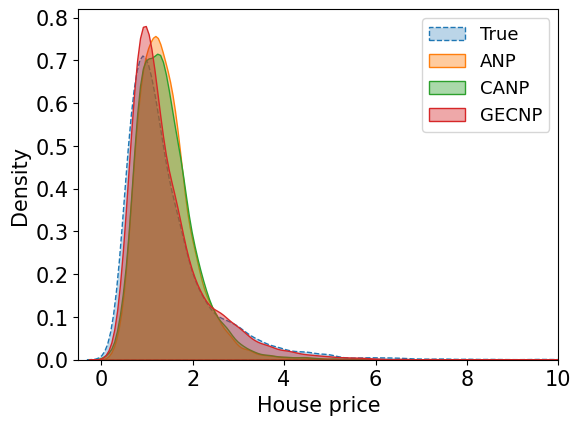

In [37]:

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from libpysal.weights import KNN
from esda.moran import Moran
import os
import seaborn as sns
import numpy as np
# # # # # #Chengdu  分布拟合图


# 生成数据分布拟合
fig = plt.plot( figsize=(3,2)) #创建画
data_frame=pd.read_csv(r'F:/论文投稿\5.MoxNP - 副本/Latex Source file/Figure/chengdu_prediction_val_1.csv')
#id	s1	s2		TRUE	gegcn_pred	anp_pred  canp_pred   
data_frame=np.array(data_frame)
true=data_frame[:,3]
pred_gcn=data_frame[:,7]
pred_gat=data_frame[:,5]
pred_sage=data_frame[:,6]
sns.kdeplot(true, alpha=0.3,label="True", linestyle='--',fill=True)
sns.kdeplot(pred_gat, alpha=0.4,label="ANP", fill=True)

sns.kdeplot(pred_sage, alpha=0.4,label="CANP", fill=True)
sns.kdeplot(pred_gcn, alpha=0.4,label="GECNP", fill=True)

plt.legend(loc='upper right',fontsize=13)
plt.ylabel("Density",size=15)
plt.xlabel("House price",size=15)
plt.xlim((-0.5,10))
plt.subplots_adjust(left=0.15, bottom=0.15)
plt.xticks(fontsize=15)  # 设置x 轴数值的字体大小为 15
plt.yticks(fontsize=15)  # 设置 y 轴数值的字体大小为 15
# plt.savefig('F:\MoxNP\Latex Source file\Figure/Chengdu_distribution.png',dpi=500)
plt.show()




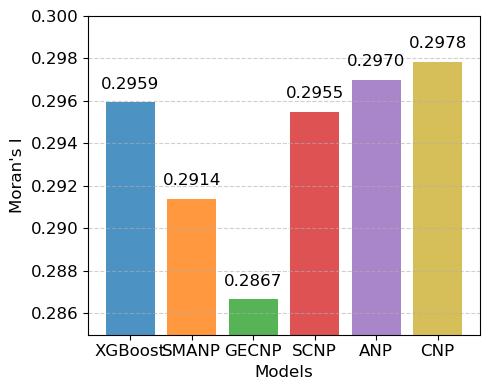

In [32]:

import matplotlib.pyplot as plt
import numpy as np

# 模型名称和Moran值
models = ['XGBoost','SMANP','GECNP','SCNP','ANP','CNP']
Moran = [0.29594000191999314,0.2914000191999314,0.28666619797520143,0.29548499902368064,0.2970059443521799,0.2978499912368022,]

# 设置图形大小
plt.figure(figsize=(5,4))

# 画柱状图
bars = plt.bar(models, Moran, color=['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd',"#ccaf30"], alpha=0.8)

# 在柱子上方显示数值
for bar, value in zip(bars, Moran):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
             f"{value:.4f}", ha='center', va='bottom', fontsize=12)

# 添加标题和坐标轴标签
plt.ylabel("Moran's I",fontsize=12)
plt.xlabel("Models", fontsize=12)
# plt.title("Comparison of Moran's I across Models", fontsize=14)

plt.ylim(0.285, 0.300)  # 调整y轴范围，使差异更明显
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tick_params(labelsize=12)
plt.tight_layout()
# plt.savefig(r'F:\MoxNP\Latex Source file\Figure/Moran1.png')
plt.show()


(2797, 7)


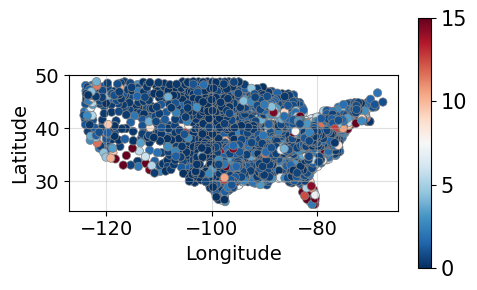

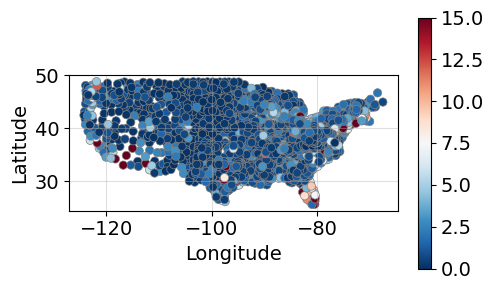

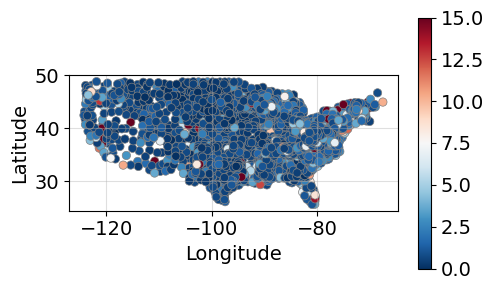

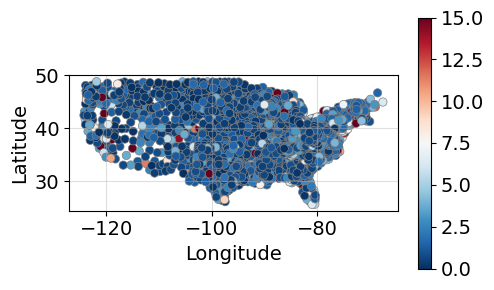

complete


In [23]:

##chengdu visilization

import geopandas as gpd
from shapely.geometry import Point
import geopandas as gp
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numpy as np
from matplotlib.ticker import FuncFormatter

# # 验证集

file_path = 'F:/论文投稿/5.MoxNP - 副本/Latex Source file/Figure/election_prediction_val_0.csv'


datatype={'var_y',np.float32}
rankings_colname = ['id','Longitude','Latitude', 'TRUE', 'gecnp_pred','anp_pred','cnp_pred']
df = pd.read_csv(file_path, header=None, names=rankings_colname)
df=df.astype(np.float32)
# df = df.sample(frac=0.9, random_state=42)  # 10% 抽样
print(df.shape)


xy = [Point(xy) for xy in zip(df['Longitude'], df['Latitude'])]
pts = gpd.GeoSeries(xy)  # 创建点要素数据集
#保存为SHP文件
# pts.to_file('./1.shp', driver='ESRI Shapefile', encoding='utf-8')

georgia_data = pd.read_csv(file_path)
georgia_shp = gp.read_file('F:/论文投稿/5.MoxNP - 副本/Latex Source file/Figure/1.shp')


## 真实观测

var_names = ['TRUE']
gwr_coefficent =pd.DataFrame(df['TRUE'])
georgia_data_geo = gp.GeoDataFrame(df, geometry=gp.points_from_xy(df['Longitude'], df['Latitude']))
georgia_data_geo = georgia_data_geo.merge(gwr_coefficent)
georgia_shp_geo = gp.sjoin(georgia_shp, georgia_data_geo, how="inner", predicate='intersects').reset_index()
fig, ax = plt.subplots(figsize=(5,3))

# ax.set_title(var_names)
plot=georgia_shp_geo.plot(ax=ax, column=var_names[0],edgecolor='gray', linewidth=0.5, alpha=1.0, cmap='RdBu_r', legend=True, vmin=0, vmax=15)
# 获取颜色棒对象
cbar = plot.get_figure().get_axes()[-1]  # 颜色棒通常是最后一个Axes对象

# 设置颜色棒刻度字体大小
cbar.tick_params(labelsize=15)  # 设置颜色棒刻度字体大小

ax.tick_params(axis='x', labelsize=14)  # 设置横轴字体大小
ax.tick_params(axis='y', labelsize=14)  # 设置纵轴字体大小
plt.ylabel('Latitude',size=14)
plt.xlabel('Longitude',size=14)
plt.grid(True, alpha=0.4)  # 显示网格，透明度为50%
# ax.legend(title="House", loc='upper right', ncol=1)  # 添加图例
plt.tight_layout()
# plt.savefig(r'F:\MoxNP\Latex Source file\Figure//True.png',dpi=500)




# gecnp观测

var_names1 = ['gecnp_pred']
gwr_coefficent1 =pd.DataFrame(df['gecnp_pred'])
georgia_data_geo1 = gp.GeoDataFrame(df, geometry=gp.points_from_xy(df['Longitude'], df['Latitude']))
georgia_data_geo1 = georgia_data_geo1.merge(gwr_coefficent1)
georgia_shp_geo1 = gp.sjoin(georgia_shp, georgia_data_geo1, how="inner", predicate='intersects').reset_index()
fig, ax = plt.subplots(figsize=(5,3))

# ax.set_title(var_names)
plot=georgia_shp_geo1.plot(ax=ax, column=var_names1[0],edgecolor='gray', linewidth=0.5, alpha=1.0, cmap='RdBu_r', legend=True, vmin=0, vmax=15)
# 获取颜色棒对象
cbar = plot.get_figure().get_axes()[-1]  # 颜色棒通常是最后一个Axes对象

# 设置颜色棒刻度字体大小
cbar.tick_params(labelsize=14)  # 设置颜色棒刻度字体大小

ax.tick_params(axis='x', labelsize=14)  # 设置横轴字体大小
ax.tick_params(axis='y', labelsize=14)  # 设置纵轴字体大小
plt.ylabel('Latitude',size=14)
plt.xlabel('Longitude',size=14)
plt.grid(True, alpha=0.4)  # 显示网格，透明度为50%
# ax.legend(title="House", loc='upper right', ncol=1)  # 添加图例
plt.tight_layout()
# plt.savefig(r'F:\MoxNP\Latex Source file\Figure//gecnp_pred.png',dpi=500)
plt.show()



##anp观测

var_names2 = ['anp_pred']
gwr_coefficent2 =pd.DataFrame(df['anp_pred'])
georgia_data_geo2 = gp.GeoDataFrame(df, geometry=gp.points_from_xy(df['Longitude'], df['Latitude']))
georgia_data_geo2 = georgia_data_geo1.merge(gwr_coefficent2)
georgia_shp_geo2 = gp.sjoin(georgia_shp, georgia_data_geo2, how="inner", predicate='intersects').reset_index()
fig, ax = plt.subplots(figsize=(5,3))

# ax.set_title(var_names)
plot=georgia_shp_geo2.plot(ax=ax, column=var_names2[0],edgecolor='gray', linewidth=0.5, alpha=1.0, cmap='RdBu_r', legend=True, vmin=0, vmax=15)
# 获取颜色棒对象
cbar = plot.get_figure().get_axes()[-1]  # 颜色棒通常是最后一个Axes对象

# 设置颜色棒刻度字体大小
cbar.tick_params(labelsize=14)  # 设置颜色棒刻度字体大小

ax.tick_params(axis='x', labelsize=14)  # 设置横轴字体大小
ax.tick_params(axis='y', labelsize=14)  # 设置纵轴字体大小
plt.ylabel('Latitude',size=14)
plt.xlabel('Longitude',size=14)
plt.grid(True, alpha=0.4)  # 显示网格，透明度为50%
# ax.legend(title="House", loc='upper right', ncol=1)  # 添加图例
plt.tight_layout()
# plt.savefig(r'F:\MoxNP\Latex Source file\Figure//anp_pred.png',dpi=500)
plt.show()



##cnp观测

var_names3 = ['cnp_pred']
gwr_coefficent3 =pd.DataFrame(df['cnp_pred'])
georgia_data_geo3 = gp.GeoDataFrame(df, geometry=gp.points_from_xy(df['Longitude'], df['Latitude']))
georgia_data_geo3 = georgia_data_geo1.merge(gwr_coefficent3)
georgia_shp_geo3 = gp.sjoin(georgia_shp, georgia_data_geo3, how="inner", predicate='intersects').reset_index()
fig, ax = plt.subplots(figsize=(5,3))

# ax.set_title(var_names)
plot=georgia_shp_geo3.plot(ax=ax, column=var_names3[0],edgecolor='gray', linewidth=0.5, alpha=1.0, cmap='RdBu_r', legend=True, vmin=0, vmax=15)
# 获取颜色棒对象
cbar = plot.get_figure().get_axes()[-1]  # 颜色棒通常是最后一个Axes对象

# 设置颜色棒刻度字体大小
cbar.tick_params(labelsize=14)  # 设置颜色棒刻度字体大小

ax.tick_params(axis='x', labelsize=14)  # 设置横轴字体大小
ax.tick_params(axis='y', labelsize=14)  # 设置纵轴字体大小
plt.ylabel('Latitude',size=14)
plt.xlabel('Longitude',size=14)
plt.grid(True, alpha=0.4)  # 显示网格，透明度为50%
# ax.legend(title="House", loc='upper right', ncol=1)  # 添加图例
plt.tight_layout()
# plt.savefig(r'F:\MoxNP\Latex Source file\Figure//cnp_pred.png',dpi=500)
plt.show()

print("complete")



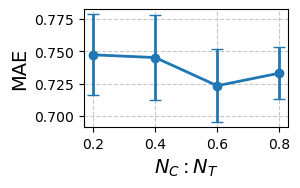

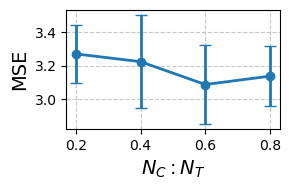

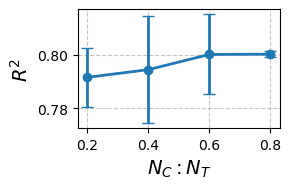

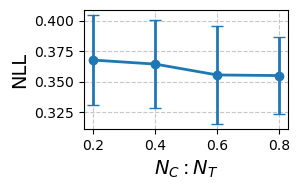

In [22]:

##N_C:NT

import numpy as np
import matplotlib.pyplot as plt


results = {
    '0.2': ([0.7472, 3.2700, 0.7916, 0.3678], [0.0313,0.1748, 0.0111, 0.0366]),
    '0.4': ([0.7451, 3.2236, 0.7945, 0.3645], [0.0327,0.2764, 0.0200, 0.0358]),
    '0.6': ([0.7233, 3.0873, 0.8002, 0.3556], [0.0281,0.2358, 0.0150, 0.0402]),
    '0.8': ([0.7330, 3.1372, 0.8003, 0.3551], [0.0200,0.1780, 0.0011, 0.0316])
}


ratios = list(results.keys())
data = np.array(list(results.values()))  # shape: (4, 3)
metrics = ['MAE', "MSE",r'$R^2$', 'NLL']

# 取均值和标准差为数组
means = np.array([results[r][0] for r in ratios])
stds = np.array([results[r][1] for r in ratios])

# 分别为每个指标绘制带误差棒的折线图
for i, metric in enumerate(metrics):
    plt.figure(figsize=(3, 2))
    plt.errorbar(
        ratios,
        means[:, i],
        yerr=stds[:, i],
        marker='o',
        capsize=4,
        linewidth=2,
        label=metric
    )
    # plt.title(f'{metric} vs Context Ratio', fontsize=14)
    plt.xlabel(r'$N_C : N_T$', fontsize=14)
    plt.ylabel(metric, fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    # plt.savefig(r'F:\MoxNP\Latex Source file\Figure/C_T_{}.png'.format(metric))

plt.show()



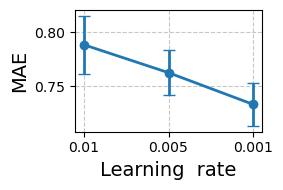

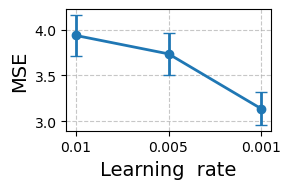

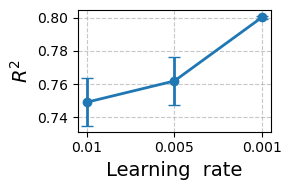

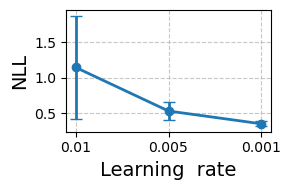

In [21]:

##learning rate

import numpy as np
import matplotlib.pyplot as plt

results = {
    '0.01':   ([0.7885, 3.9359, 0.7491, 1.1477], [0.0271,0.2274,0.0145,0.7295]),
    '0.005': ([0.7625, 3.7350, 0.7619, 0.5347], [0.0208,0.2257,0.0144,0.1226]),
    '0.001': ([0.7330, 3.1372, 0.8003, 0.3551], [0.0202,0.1784,0.0011,0.0336])
}


ratios = list(results.keys())
data = np.array(list(results.values()))  # shape: (4, 3)
metrics = ['MAE', "MSE",r'$R^2$', 'NLL']

# 取均值和标准差为数组
means = np.array([results[r][0] for r in ratios])
stds = np.array([results[r][1] for r in ratios])

# 分别为每个指标绘制带误差棒的折线图
for i, metric in enumerate(metrics):
    plt.figure(figsize=(3, 2))
    plt.errorbar(
        ratios,
        means[:, i],
        yerr=stds[:, i],
        marker='o',
        capsize=4,
        linewidth=2,
        label=metric
    )
    # plt.title(f'{metric} vs Context Ratio', fontsize=14)
    plt.xlabel(' Learning  rate ', fontsize=14)
    plt.ylabel(metric, fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    # plt.savefig(r'F:\MoxNP\Latex Source file\Figure/lr_{}.png'.format(metric))

plt.show()





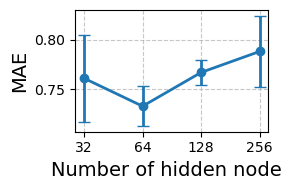

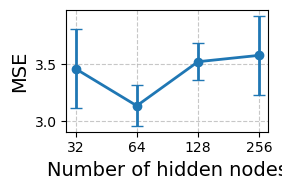

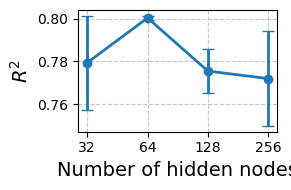

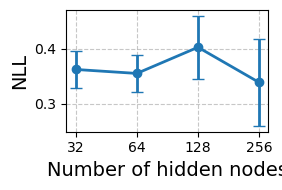

In [20]:

# # ##hidden num

import numpy as np
import matplotlib.pyplot as plt

results = {
    '32':   ([0.7612, 3.4608, 0.7794, 0.3623], [0.0440,0.3454,0.0220,0.0341]),
    '64':   ([0.7330, 3.1372, 0.8003, 0.3551], [0.0202,0.1784,0.0011,0.0336]),
    '128': ([0.7671, 3.5223, 0.7755, 0.4025], [0.0125,0.1633,0.0104,0.0575]),
    '256': ([0.7883, 3.5780, 0.7720, 0.3387], [0.0363,0.3478 ,0.0222,0.0792])
}

ratios = list(results.keys())
data = np.array(list(results.values()))  # shape: (4, 3)
metrics = ['MAE', "MSE",r'$R^2$', 'NLL']

# 取均值和标准差为数组
means = np.array([results[r][0] for r in ratios])
stds = np.array([results[r][1] for r in ratios])

# 分别为每个指标绘制带误差棒的折线图
for i, metric in enumerate(metrics):
    plt.figure(figsize=(3,2))
    plt.errorbar(
        ratios,
        means[:, i],
        yerr=stds[:, i],
        marker='o',
        capsize=4,
        linewidth=2,
        label=metric
    )
    # plt.title(f'{metric} vs Context Ratio', fontsize=14)
    plt.xlabel('Number of hidden nodes', fontsize=14)
    plt.ylabel(metric, fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    # plt.savefig(r'F:\MoxNP\Latex Source file\Figure/d_h_{}.png'.format(metric))

plt.show()

